In [ ]:
#!/usr/bin/env python3
from datetime import datetime
import gymnasium as gym
import rospy 
import cv2
from cv_bridge import CvBridge, CvBridgeError
from sensor_msgs.msg import Image,Imu,LaserScan
from geometry_msgs.msg import Twist,Vector3
import queue
from gymnasium.spaces import Dict,Box
import numpy as np
from queue import Queue
import time
from jaxrl2.data import VariableCapacityBuffer,ReplayBuffer
import message_filters

In [3]:
rospy.init_node("DATA_FILTER", anonymous=False)

In [4]:
IMAGE_TOPIC="/camera/image_raw"
IMU_TOPIC="/imu/data_raw"
ROBOT_CMD_TOPIC="/cmd_vel"
LIDAR_TOPIC="/scan"
RATE = 60
DT=1/RATE

In [5]:
def ros_vector3_to_np_array(msg):
    return np.array([msg.x,-1*msg.y,msg.z])

In [6]:
bridge=CvBridge()
image_size=64
hold_action_queue=True
# Define Queue
image_queue=Queue()
imu_queue=Queue()
lidar_queue=Queue()
action_queue=Queue()


#
image_space = Box(
            low=-1.0,
            high=1.0,
            shape=(image_size, image_size, 3,),
            dtype=np.float32,
        )
        
vec_space = Box(
    low=-5.1,
    high=5.1,
    shape=(4,),
    dtype=np.float32,
)

observation_space=Dict({"pixels":image_space, "vector":vec_space})

action_space = Box(
    low=np.array([-1.0, -1.0]),  # [steering, throttle/brake]
    high=np.array([1.0, 1.0]),
    dtype=np.float32
)
def image_callback(image):
    # print("image")
    image = bridge.imgmsg_to_cv2(image, "rgb8")
    image=cv2.resize(image,(image_size,image_size))
    image_queue.put(image)

def imu_callback(imu):
    payload=dict(w=ros_vector3_to_np_array(imu.angular_velocity),a=ros_vector3_to_np_array(imu.linear_acceleration))
    imu_queue.put(payload)

def lidar_callback(scan):
    lidar_queue.put(scan)

def action_callback(action):
    global hold_action_queue
    if not hold_action_queue:
        action_queue.put(action)
        hold_action_queue = True



/root/.local/share/virtualenvs/carla-rl-CUcVYiBV/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/root/.local/share/virtualenvs/carla-rl-CUcVYiBV/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [7]:

# image_sub = rospy.Subscriber(IMAGE_TOPIC,Image,image_callback)
# lidar_sub = rospy.Subscriber(LIDAR_TOPIC,LaserScan,lidar_callback)
# imu_sub = rospy.Subscriber(IMU_TOPIC,Imu,imu_callback)



def callback(image,lidar,imu):
    global hold_action_queue
    hold_action_queue = False
    imu_callback(imu)
    image_callback(image)
    lidar_callback(lidar)
    # action_callback(action)

image_sub = message_filters.Subscriber(IMAGE_TOPIC,Image)
lidar_sub = message_filters.Subscriber(LIDAR_TOPIC,LaserScan)
imu_sub = message_filters.Subscriber(IMU_TOPIC,Imu)
# robot_cmd = message_filters.Subscriber(ROBOT_CMD_TOPIC,Twist)
ts = ts = message_filters.ApproximateTimeSynchronizer([image_sub,lidar_sub,imu_sub], 15,1,True)
ts.registerCallback(callback)

robot_cmd =rospy.Subscriber(ROBOT_CMD_TOPIC, Twist, action_callback)

time.sleep(1.0)

step=0
#put everything in a list becuase we need some metrics
a=[]
w=[]
scans=[]
images=[]
actions=[]
# rospy.spin()
while True:
    # continue
    # time.sleep(2.0)
    print("action",action_queue.qsize())
    action=action_queue.get()
    print("image",image_queue.qsize())
    image=image_queue.get()
    print("imu",imu_queue.qsize())
    imu=imu_queue.get()
    print("lidar",lidar_queue.qsize())
    scan=lidar_queue.get()


    # print("Image",image)
    a.append(imu.get("a"))
    w.append(imu.get("w"))
    scans.append(scan)
    actions.append([action.angular.z,action.linear.x])   #steer throttle
    images.append(image)
    # action_queue.queue.clear()
    time.sleep(4)

    if (image_queue.empty() or imu_queue.empty() or lidar_queue.empty() or action_queue.empty()):
        break

    # more data
    # image_queue.put(image)
    # imu=imu_queue.get(imu)
    # scan=lidar_queue.put(scan)
    # step+=1




action 0
image 1
imu 1
lidar 1
action 18
image 18
imu 18
lidar 18
action 35
image 35
imu 35
lidar 35
action 43
image 43
imu 43
lidar 43
action 53
image 53
imu 53
lidar 53
action 64
image 65
imu 65
lidar 65
action 79
image 80
imu 80
lidar 80
action 79
image 80
imu 80
lidar 80
action 87
image 89
imu 89
lidar 89
action 94
image 95
imu 95
lidar 95
action 107
image 109
imu 109
lidar 109
action 109
image 110
imu 110
lidar 110
action 128
image 129
imu 129
lidar 129
action 145
image 146
imu 146
lidar 146
action 158
image 160
imu 160
lidar 160
action 162
image 165
imu 165
lidar 165
action 179
image 181
imu 181
lidar 181
action 190
image 192
imu 192
lidar 192
action 195
image 197
imu 197
lidar 197
action 196
image 199
imu 199
lidar 199
action 210
image 213
imu 213
lidar 213
action 218
image 221
imu 221
lidar 221
action 220
image 223
imu 223
lidar 223
action 227
image 230
imu 230
lidar 230
action 238
image 241
imu 241
lidar 241
action 251
image 255
imu 255
lidar 255
action 252
image 256
imu 256
l

In [8]:
from scipy.signal import filtfilt, butter

def estimate_orientation(a, w, angle,dt, alpha=0.9, theta_min=1e-6):
    """
    Source:https://gist.github.com/phausamann/721fa3df0f8ef6f4f6f24b86fdde53c0
    """
    w[np.linalg.norm(w) < theta_min] = 0
    angle = (1-alpha)*(angle + w * dt) + (alpha)*(a)
    return angle

In [9]:
# a=(a)
# w=np.array(w)
# angle=np.zeros((3,))
# heading=estimate_orientation(a,w,angle,dt=DT)
# a=np.array(a)

In [10]:
def mean_distance_to_obstacle(scan):
        angles = np.arange(
            scan.angle_min,
            scan.angle_max + scan.angle_increment,
            scan.angle_increment
        )
        
        selected_indices = np.ravel(np.argwhere(
            np.logical_and(
                np.logical_or(
                    angles < np.pi/2,  # Less than 90 degrees
                    angles > np.pi*(3/2)  # Greater than 270 degrees
                ),
                np.array(scan.ranges) > scan.range_min
            )
        ))
        # print(selected_indices)
        # Update ranges using only the selected indices
        ranges=np.array(scan.ranges)
        collision=np.min(ranges[selected_indices])
        return collision        

In [11]:

# from collections import deque


# v=np.zeros((3,))
# vs=[]
# speeds=[]
# angle=np.zeros((3,))
# # filter_headings=[]
# headings=[]
# # smoothed_heading=[]
# distance_to_obstacle=[]
# observation=None
# p_action=np.zeros((2,))
# replay_buffer = VariableCapacityBuffer(
#         observation_space,
#         action_space)
# done=False

# while replay_buffer._size<int(1e6):
#     target_speed=np.random.uniform(0.01,0.4)
#     target_heading=np.random.uniform(1e-8,2*np.pi)
#     collision_threshold=0.4
#     for i in range(len(a)):
        
#         _a=a[i]
#         _a[2]=0
#         v=v+_a*DT
#         action=actions[1]
#         angle=estimate_orientation(_a,w[i],angle,dt=DT,alpha=0.1)
#         dist_to_obs=mean_distance_to_obstacle(scans[i])
#         distance_to_obstacle.append(dist_to_obs)
#         headings.append(angle[2])
#         vs.append(v)
#         speed=np.linalg.norm(v)
#         speeds.append(speed)
#         vec=np.zeros(4)


#         vec[0]=p_action[0]/1.0
#         vec[1]=p_action[1]/1.0
#         vec[2]=np.clip(speed/(target_speed+1.0),0,5.1)
#         vec[3]=np.clip((angle[2]/target_heading+1.0),-5.1,5.1)


#         speed_factor=np.exp(-(speed-target_speed)**2)

#         # Normalize heading error to [-1.0, 1.0] to allow for larger corrections
#         heading_factor = np.exp(-(angle[2]-target_heading)**2)
#         # heading_error = np.clip(heading_error, -1.0, 1.0)

#         # Calculate smooth action penalty to encourage smoother control inputs
#         action_factor = np.exp(-np.sum(np.subtract(p_action,action)**2))


#         reward=  2.0*speed_factor + 0.5*action_factor + heading_factor
#         # print(np.max(images[i]))
#         next_observation=dict(pixels=np.array(images[i]).astype(np.float32)[...,None]/255,vector=vec)
#         if observation is None:
#             observation=next_observation
            
#         if dist_to_obs<=collision_threshold:
#             done=True
#             reward-=10

#         if speed>target_speed:
#             done=True
#             reward-=10
            
#         mask=1-int(done)
#         replay_buffer.insert(
#             dict(
#                 observations=observation,
#                 actions=action,
#                 rewards=reward,
#                 masks=mask,
#                 dones=done,
#                 next_observations=next_observation,
#             )
#         )
#         p_action=action
#         observation=next_observation
#         done=False


# print("Target Speed",np.mean(speeds))
# print("Target Heading",np.rad2deg(np.max(headings)))

In [12]:
from collections import deque
import numpy as np
import cv2

def augment_image(image, augmentation_intensity=0.3):
    aug_image = image.copy()
    
    if np.random.random() < 0.5:
        brightness_factor = np.random.uniform(1-augmentation_intensity, 1+augmentation_intensity)
        aug_image = np.clip(aug_image * brightness_factor, 0, 1)
    
    if np.random.random() < 0.5:
        contrast_factor = np.random.uniform(1-augmentation_intensity, 1+augmentation_intensity)
        aug_image = np.clip((aug_image - 0.5) * contrast_factor + 0.5, 0, 1)
    
    # if np.random.random() < 0.5:
    #     height, width = aug_image.shape[:2]
    #     angle = np.random.uniform(-5, 5) * augmentation_intensity
    #     M = cv2.getRotationMatrix2D((width/2, height/2), angle, 1)
    #     aug_image = cv2.warpAffine(aug_image, M, (width, height), borderMode=cv2.BORDER_REPLICATE)
    
    # if np.random.random() < 0.3:
    #     aug_image = np.fliplr(aug_image)
    
    return aug_image

def add_vector_noise(vector, noise_scale=0.05):
    return vector + np.random.normal(0, noise_scale, size=vector.shape)

v = np.zeros((3,))
vs = []
speeds = []
angle = np.zeros((3,))
headings = []
distance_to_obstacle = []
observation = None
p_action = np.zeros((2,))
replay_buffer = ReplayBuffer(
    observation_space,
    action_space,
    int(1e5)
    )
done = False

use_augmentation = True
augmentation_probability = 0.5
noise_scale = 0.03

while replay_buffer._size < int(2e4):
    target_speed = np.random.uniform(0.01, 0.4)
    target_heading = np.random.uniform(1e-8, 2*np.pi)
    collision_threshold = 0.4
    v = np.zeros((3,))
    for i in range(len(a)):
        _a = a[i]
        _a[2] = 0
        v = v + _a*DT
        action = actions[1]
        angle = estimate_orientation(_a, w[i], angle, dt=DT, alpha=0.1)
        dist_to_obs = mean_distance_to_obstacle(scans[i])
        distance_to_obstacle.append(dist_to_obs)
        headings.append(angle[2])
        vs.append(v)
        speed = np.linalg.norm(v)
        speeds.append(speed)
        
        vec = np.zeros(4)
        vec[0] = p_action[0]/1.0
        vec[1] = p_action[1]/1.0
        vec[2] = np.clip(speed/(target_speed+1.0), 0, 5.1)
        vec[3] = np.clip((angle[2]/target_heading+1.0), -5.1, 5.1)
        
        speed_factor = np.exp(-(speed-target_speed)**2)
        heading_factor = np.exp(-(angle[2]-target_heading)**2)
        action_factor = np.exp(-np.sum(np.subtract(p_action, action)**2))
        reward = 2.0*speed_factor + 0.5*action_factor + heading_factor
        
        img = np.array(images[i]).astype(np.float32)[..., None]/255
        
        vector_state = vec.copy()
        if use_augmentation and np.random.random() < augmentation_probability:
            vector_state = add_vector_noise(vector_state, noise_scale)
        
        next_observation = dict(
            pixels=img,
            vector=vector_state
        )
        
        if observation is not None and use_augmentation and np.random.random() < augmentation_probability:
            aug_img = augment_image(observation['pixels'])
            aug_vector = add_vector_noise(observation['vector'], noise_scale)
            aug_observation = dict(pixels=aug_img, vector=aug_vector)
            
            aug_next_img = augment_image(next_observation['pixels'])
            aug_next_vector = add_vector_noise(next_observation['vector'], noise_scale)
            aug_next_observation = dict(pixels=aug_next_img, vector=aug_next_vector)
            
            replay_buffer.insert(
                dict(
                    observations=aug_observation,
                    actions=action,
                    rewards=reward,
                    masks=mask,
                    dones=done,
                    next_observations=aug_next_observation,
                )
            )
        
        if observation is None:
            observation = next_observation
            
        if i%200==0:
            done=True
            reward+=10

        if dist_to_obs<=collision_threshold:
            done=True
            reward-=10

        if speed>target_speed:
            done=True
            reward-=10
            
            
        mask = 1-int(done)
        
        replay_buffer.insert(
            dict(
                observations=observation,
                actions=action,
                rewards=reward,
                masks=mask,
                dones=done,
                next_observations=next_observation,
            )
        )
        
        p_action = action
        observation = next_observation
        done = False

print("Target Speed", np.mean(speeds))
print("Target Heading", np.rad2deg(np.max(headings)))
print("Buffer size:", replay_buffer._size)
print("Augmentation enabled:", use_augmentation)

NameError: name 'ReplayBuffer' is not defined

In [ ]:
replay_buffer._size

20632

In [ ]:
# headings
import glob
import os
import pickle


dataset_folder = os.path.join("datasets")
os.makedirs(dataset_folder, exist_ok=True)
count=len(glob.glob(f"{dataset_folder}/*.pkl"))
final_dataset_file = os.path.join(dataset_folder, f"leo_data_{count}.pkl")
with open(final_dataset_file, "wb") as f:
    pickle.dump(replay_buffer, f)


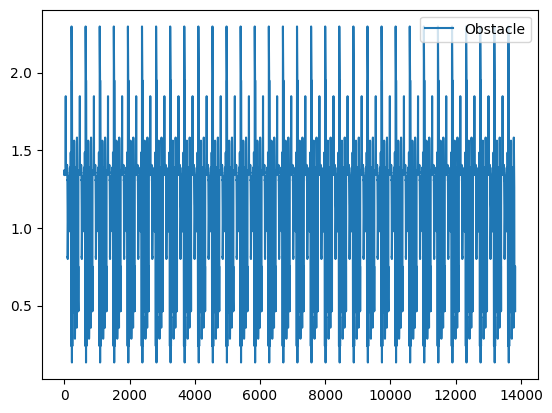

In [ ]:
import matplotlib.pyplot as plt
x=np.array(range(len(headings)))
# plt.plot(x,accel_x,label="Acceleration")
# plt.plot(x,w[:,2],label="Angular Velocity")
# plt.plot(x,heading,label="Heading")
# plt.plot(x,vs,label="Velocity")
# plt.plot(x,speed,label="Speed")
plt.plot(x,distance_to_obstacle,label="Obstacle")
# plt.plot(x,smoothed_heading,label="Smooth Heading")
plt.legend()